In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Connecting to our database
conn = sqlite3.connect("../db/nfl_aging.db")

#Loading the full dataset with SQL query
df = pd.read_sql_query("""
    SELECT s.*, p.display_name, p.college_name,
           p.draft_year, p.draft_round,
           p.height, p.weight
    FROM season_stats s
    JOIN players p ON s.player_id = p.player_id
""", conn)

print(f"Loaded {len(df)} rows")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Loaded 1613 rows

Columns: ['player_id', 'season', 'age', 'games', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_first_downs', 'rushing_epa', 'rushing_fumbles', 'receptions', 'targets', 'receiving_yards', 'receiving_tds', 'receiving_epa', 'fantasy_points', 'fantasy_points_ppr', 'display_name', 'college_name', 'draft_year', 'draft_round', 'height', 'weight']


,player_id,season,age,games,carries,rushing_yards,rushing_tds,rushing_first_downs,rushing_epa,rushing_fumbles,...,receiving_tds,receiving_epa,fantasy_points,fantasy_points_ppr,display_name,college_name,draft_year,draft_round,height,weight
0,00-0000210,2000,25,16,286,1106.0,2,56.0,-40.359270,5.0,...,1,-11.584555,149.7,188.7,James Allen,Oklahoma,NaN,NaN,70.0,215.0
1,00-0000210,2001,26,16,135,469.0,1,26.0,-12.313433,1.0,...,1,-1.915430,79.2,109.2,James Allen,Oklahoma,NaN,NaN,70.0,215.0
2,00-0000210,2002,27,16,155,519.0,0,20.0,-35.273551,1.0,...,0,-7.472205,86.3,133.3,James Allen,Oklahoma,NaN,NaN,70.0,215.0
3,00-0000232,2001,33,11,168,658.0,3,32.0,-17.968309,1.0,...,0,-3.428503,88.6,105.6,Terry Allen,Clemson,1990.0,9.0,71.0,208.0
4,00-0000279,2000,34,11,75,329.0,2,14.0,-10.427900,1.0,...,0,-1.720183,50.5,65.5,Kimble Anders,Houston,NaN,NaN,71.0,218.0


In [8]:
#Basic Summary Statistics
print(f"Seasons covered: {df['season'].min()} - {df['season'].max()}")
print(f"Unique players: {df['player_id'].nunique()}")
print(f"Age range: {df['age'].min()} - {df['age'].max()}")
print(f"\n-----RUSHING YARDS SUMMARY-----")
print(df['rushing_yards'].describe().round(1))

Seasons covered: 2000 - 2023
Unique players: 447
Age range: 21 - 37

-----RUSHING YARDS SUMMARY-----
count    1613.0
mean      667.1
std       382.5
min       130.0
25%       348.0
50%       581.0
75%       933.0
max      2097.0
Name: rushing_yards, dtype: float64


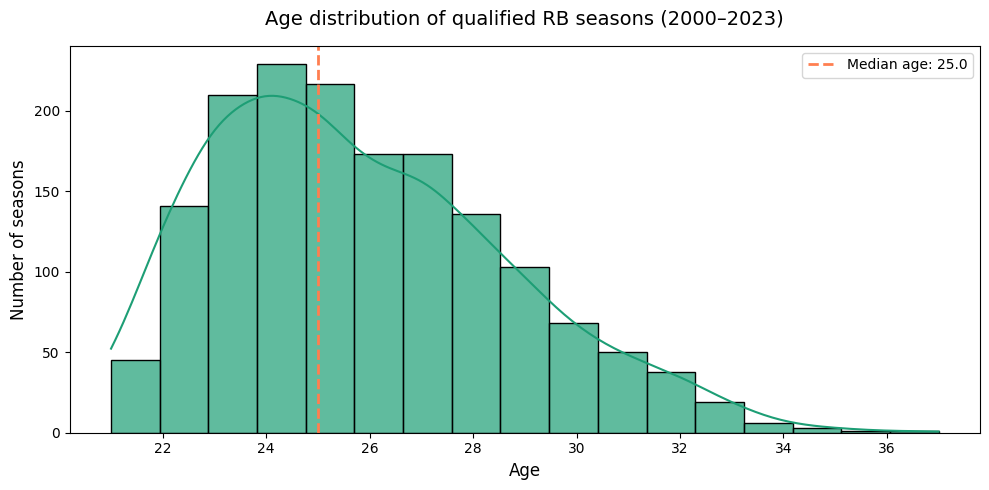

In [9]:
#Age distribution of qualified RB seasons
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data=df, x="age", bins=17, kde=True, 
             color="#1D9E75", alpha=0.7, ax=ax)

ax.set_title("Age distribution of qualified RB seasons (2000–2023)", 
             fontsize=14, pad=15)
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Number of seasons", fontsize=12)
ax.axvline(df['age'].median(), color='coral', 
           linestyle='--', linewidth=2, 
           label=f"Median age: {df['age'].median()}")
ax.legend()

plt.tight_layout()
plt.show()

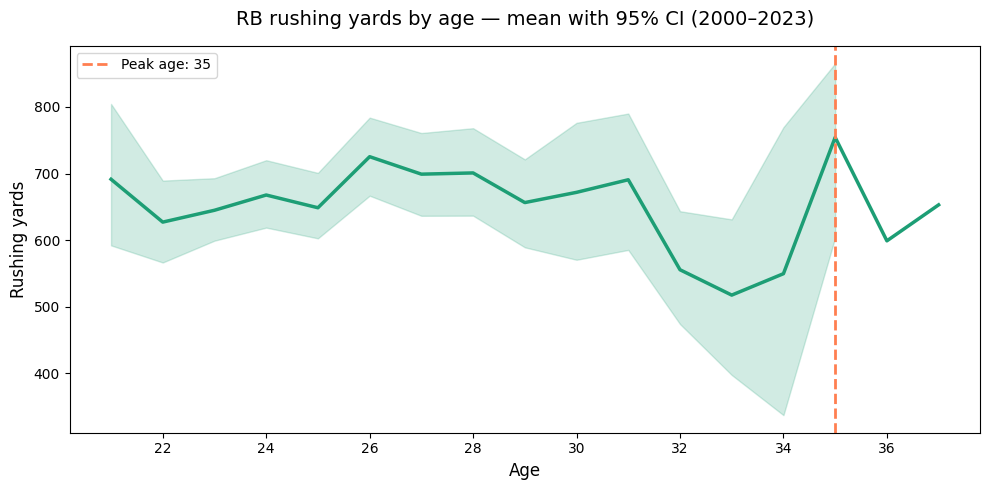

Peak rushing yards at age: 35
Mean rushing yards at peak: 754.3


In [10]:
#Average rushing yards by age with confidence interval
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(data=df, x="age", y="rushing_yards",
             estimator="mean", errorbar="ci",
             color="#1D9E75", linewidth=2.5,
             err_kws={"alpha": 0.2}, ax=ax)

ax.set_title("RB rushing yards by age — mean with 95% CI (2000–2023)",
             fontsize=14, pad=15)
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Rushing yards", fontsize=12)

# Mark the peak
peak_age = df.groupby("age")["rushing_yards"].mean().idxmax()
peak_yards = df.groupby("age")["rushing_yards"].mean().max()
ax.axvline(peak_age, color="coral", linestyle="--",
           linewidth=2, label=f"Peak age: {peak_age}")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Peak rushing yards at age: {peak_age}")
print(f"Mean rushing yards at peak: {peak_yards:.1f}")

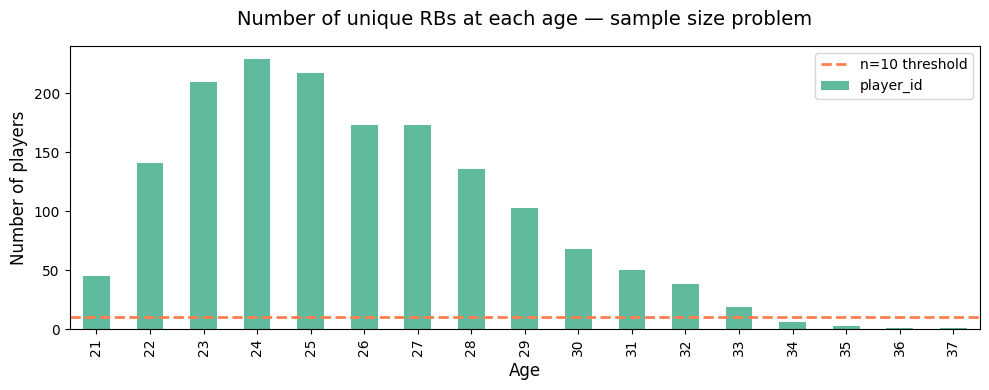


Players per age:
age
21     45
22    141
23    210
24    229
25    217
26    173
27    173
28    136
29    103
30     68
31     50
32     38
33     19
34      6
35      3
36      1
37      1


In [11]:
#Show how few players exist at older ages
age_counts = df.groupby("age")["player_id"].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
age_counts.plot(kind="bar", color="#1D9E75", alpha=0.7, ax=ax)
ax.set_title("Number of unique RBs at each age — sample size problem", 
             fontsize=14, pad=15)
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Number of players", fontsize=12)
ax.axhline(10, color="coral", linestyle="--", 
           linewidth=2, label="n=10 threshold")
ax.legend()

plt.tight_layout()
plt.show()

print("\nPlayers per age:")
print(age_counts.to_string())